In [1]:
import os
import sys
import random
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

SEED = 1337

# Fix TF/protobuf crash: force pure-Python protobuf before any TF import (do NOT use setdefault)
os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION"] = "python"
os.environ["PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION_VERSION"] = "2"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
os.environ["TF_DETERMINISTIC_OPS"] = "1"

random.seed(SEED)
np.random.seed(SEED)



In [2]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Nadam
from tensorflow.keras.utils import to_categorical

try:
    tf.random.set_seed(SEED)
except Exception:
    pass



2026-01-10 01:49:01.786820: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1768009741.798139      11 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1768009741.801403      11 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [3]:
from pylab import rcParams

rcParams["figure.figsize"] = (10, 10)



In [4]:
TRAIN_PATH = "/kaggle/input/leaf-classification/train.csv"
TEST_PATH = "/kaggle/input/leaf-classification/test.csv"
SAMPLE_SUB_PATH = "/kaggle/input/leaf-classification/sample_submission.csv"

data = pd.read_csv(TRAIN_PATH)
parent_data = data.copy()  # keep original
train_id = data.pop("id")



In [5]:
data.shape



(891, 193)

In [6]:
y_raw = data.pop("species")
le = LabelEncoder()
y = le.fit_transform(y_raw)
print(y.shape)



(891,)


In [7]:
scaler = StandardScaler()
X = scaler.fit_transform(data.values).astype(np.float32)
print(X.shape)



(891, 192)


In [8]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X, y, test_size=0.15, random_state=SEED, stratify=y
)
num_classes = len(le.classes_)

Y_tr = to_categorical(y_tr, num_classes=num_classes)
Y_val = to_categorical(y_val, num_classes=num_classes)

label_smooth = 0.01
Y_tr = Y_tr * (1.0 - label_smooth) + (label_smooth / num_classes)

print("Train:", X_tr.shape, Y_tr.shape, "Val:", X_val.shape, Y_val.shape)



Train: (757, 192) (757, 99) Val: (134, 192) (134, 99)


In [9]:
model = Sequential()
model.add(Dense(1024, input_dim=X.shape[1], activation="relu"))
model.add(Dropout(0.5))
model.add(Dense(1024, activation="relu"))
model.add(Dropout(0.5))
model.add(Dense(num_classes, activation="softmax"))

model.compile(
    loss="categorical_crossentropy",
    optimizer=Nadam(),
    metrics=["accuracy"],
)

history_obj = model.fit(
    X_tr,
    Y_tr,
    validation_data=(X_val, Y_val),
    epochs=150,
    batch_size=128,
    verbose=0,
)

history = history_obj.history



/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-01-10 01:49:08.377599: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
2026-01-10 01:49:08.528312: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchr

In [10]:
val_acc_key = (
    "val_accuracy"
    if "val_accuracy" in history
    else ("val_acc" if "val_acc" in history else None)
)
if val_acc_key is None:
    print("No validation accuracy key found in history keys:", list(history.keys()))
else:
    print("Best val acc:", float(np.max(history[val_acc_key])))



Best val acc: 1.0


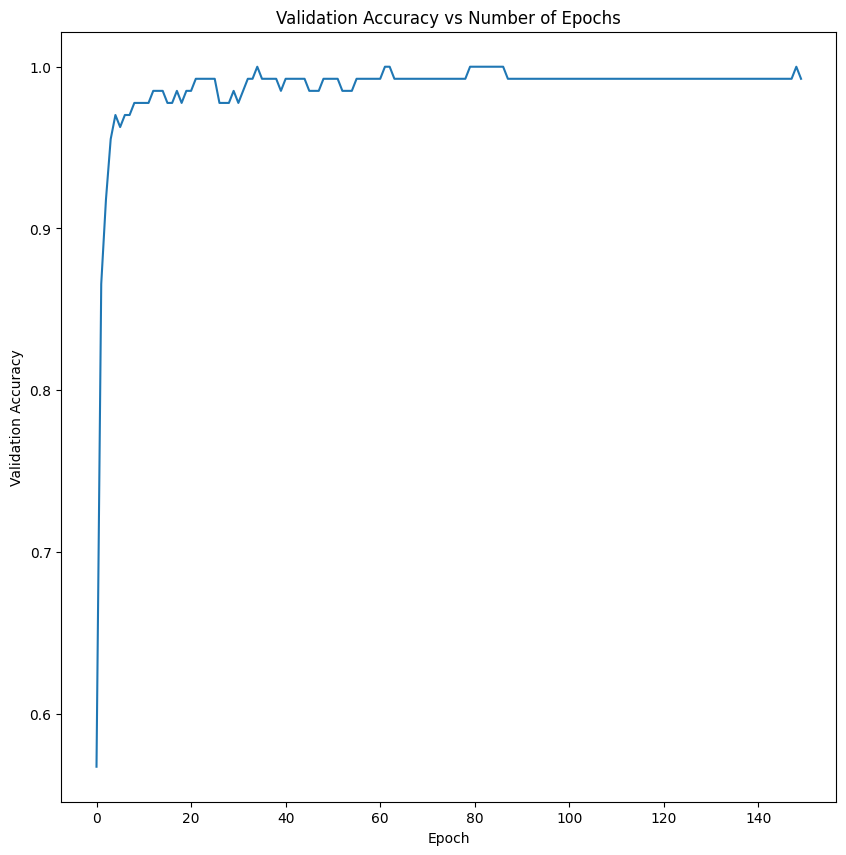

In [11]:
plt.figure()
plt.title("Validation Accuracy vs Number of Epochs")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
if val_acc_key is not None:
    plt.plot(history[val_acc_key])
plt.show()



In [12]:
test = pd.read_csv(TEST_PATH)



In [13]:
test_id = test.pop("id")
X_test = scaler.transform(test.values).astype(np.float32)

yPred = model.predict(X_test, batch_size=256, verbose=0)

temp = 0.95
yPred = np.power(yPred, 1.0 / temp)

eps = 1e-15
yPred = np.clip(yPred, eps, 1.0 - eps)
yPred = yPred / yPred.sum(axis=1, keepdims=True)



2026-01-10 01:49:26.399380: E tensorflow/core/framework/node_def_util.cc:676] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


In [14]:
sample_sub = pd.read_csv(SAMPLE_SUB_PATH)
class_cols = [c for c in sample_sub.columns if c != "id"]

model_class_names = list(le.classes_)
pred_df = pd.DataFrame(yPred, index=test_id, columns=model_class_names)

pred_df = pred_df.reindex(columns=class_cols, fill_value=0.0)

pred_vals = pred_df.values.astype(np.float64)
pred_vals = np.clip(pred_vals, eps, 1.0 - eps)
pred_vals = pred_vals / pred_vals.sum(axis=1, keepdims=True)
pred_df.loc[:, :] = pred_vals

submission = pred_df.copy()
submission.insert(0, "id", submission.index.astype(int))

submission.head()



/tmp/ipykernel_11/860230529.py:12: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[6.67056178e-05 2.01631622e-03 1.28758023e-03 1.44495132e-04
 3.03625525e-05 1.27209756e-04 4.60290087e-05 4.09155308e-06
 3.29337392e-06 1.18680046e-04 5.09863686e-05 5.30352078e-06
 1.92848214e-04 7.60886832e-07 3.66827660e-06 1.36206879e-04
 4.26395875e-06 1.33608847e-04 8.09571095e-05 1.90947274e-06
 9.11405400e-05 1.97282873e-05 8.76374030e-05 8.73569929e-07
 4.60794278e-05 2.33851789e-06 1.77569582e-06 3.08669068e-05
 2.70321294e-05 1.64669181e-04 5.53308608e-06 1.57567607e-03
 6.43359782e-05 1.78980404e-04 8.74377726e-05 3.58658137e-04
 1.96013493e-05 3.58426136e-05 8.30069275e-05 2.73981148e-05
 1.54144091e-05 2.14447231e-05 9.93719096e-01 2.60013128e-06
 3.96550083e-07 6.20409123e-05 8.97186558e-06 1.62940490e-05
 1.84341368e-04 1.41444050e-04 7.32349510e-05 3.92288637e-06
 3.86944719e-05 2.43815291e-04 4.64033363e-06 5.868639

,id,Acer_Capillipes,Acer_Circinatum,Acer_Mono,Acer_Opalus,Acer_Palmatum,Acer_Pictum,Acer_Platanoids,Acer_Rubrum,Acer_Rufinerve,...,Salix_Fragilis,Salix_Intergra,Sorbus_Aria,Tilia_Oliveri,Tilia_Platyphyllos,Tilia_Tomentosa,Ulmus_Bergmanniana,Viburnum_Tinus,Viburnum_x_Rhytidophylloides,Zelkova_Serrata
id,,,,,,,,,,,,,,,,,,,,,
1202,1202,0.000067,0.000039,0.000272,0.000078,0.000087,0.000144,0.000095,0.000092,0.000044,...,0.000054,0.000041,0.000023,0.000142,0.000017,0.000197,0.000061,0.000038,0.000215,0.000031
992,992,0.002016,0.000155,0.000148,0.000108,0.000371,0.000135,0.000227,0.000083,0.000082,...,0.001352,0.000078,0.121916,0.000565,0.001445,0.000139,0.003482,0.000066,0.057996,0.000326
491,491,0.001288,0.000222,0.002436,0.000767,0.001854,0.002812,0.000483,0.000670,0.001748,...,0.000306,0.000385,0.000677,0.001570,0.000293,0.011495,0.000396,0.000333,0.000629,0.000468
1201,1201,0.000144,0.000184,0.000084,0.000046,0.000057,0.000054,0.000044,0.000057,0.000036,...,0.000076,0.987315,0.000038,0.000051,0.000123,0.000029,0.000037,0.000204,0.000037,0.000051
72,72,0.000030,0.000014,0.000076,0.000006,0.000018,0.000262,0.000063,0.000018,0.000004,...,0.000047,0.000011,0.000004,0.000007,0.000009,0.000049,0.000054,0.000043,0.000021,0.000003


In [15]:
SUB_PATH = "submission_nn_kernel.csv"
submission.to_csv(SUB_PATH, index=False)
print("Wrote:", SUB_PATH, "shape:", submission.shape)
print("Columns match sample:", list(submission.columns) == list(sample_sub.columns))
print(
    "Row sums (min/max):",
    float(submission.drop(columns=["id"]).sum(axis=1).min()),
    float(submission.drop(columns=["id"]).sum(axis=1).max()),
)

Wrote: submission_nn_kernel.csv shape: (99, 100)
Columns match sample: True
Row sums (min/max): 0.9999999999999994 1.0000000000000007
